# AI Startup Security Pipeline Setup — Module 1

This notebook:

- Runs **Bandit**, **Semgrep**, **PyLint**, and **Safety** on the ML training codebase
- Analyzes vulnerabilities by severity and CWE
- Generates charts for severity and CWE distribution
- Produces all three assignment deliverables:
  1. **Security Scan Results Report** (`deliverables/Module1_Security_Report.md`)
  2. **GitHub Actions Workflow** (`deliverables/security-scan.yml`)
  3. **Remediation Priority Matrix** (`deliverables/remediation_matrix.csv`)

Run this notebook from the `module1_Intro/` directory.

In [2]:
import sys
!{sys.executable} -m pip install matplotlib

In [8]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("security-reports", exist_ok=True)
os.makedirs("deliverables", exist_ok=True)

print("Environment ready. Folders created: security-reports/, deliverables/")

Environment ready. Folders created: security-reports/, deliverables/


## 1. Install tools (if needed)

In [9]:
!pip install bandit semgrep pylint safety -q
print("Tools installed.")

Tools installed.


## 2. Run security scans

This cell runs:
- Bandit (Python security linter)
- Semgrep (pattern-based scanner)
- PyLint (warnings/errors only)
- Safety (dependency vulnerabilities)

Outputs are written to `security-reports/`.

In [5]:
# Bandit (scan Python source code)
!bandit -r supporting_files -f json -o security-reports/bandit-results.json || true

# Semgrep (scan Python source code)
!semgrep --config=auto supporting_files --json --output security-reports/semgrep-results.json || true

# PyLint (warnings + errors only)
!pylint supporting_files/*.py --disable=all --enable=W,E > security-reports/pylint-results.txt || true

# Safety (scan dependencies, not source code)
!pip freeze | safety check --stdin --output json > security-reports/safety-results.json

print("All scans executed. Reports saved in security-reports/.")


[main]	INFO	profile include tests: None
[main]	INFO	profile exclude tests: None
[main]	INFO	cli include tests: None
[main]	INFO	cli exclude tests: None
[json]	INFO	JSON output written to file: security-reports/bandit-results.json

┌──── ○○○ ────┐
│ Semgrep CLI │
└─────────────┘

⠼ Loading rules from registry...                                                                                
Scanning 2 files (only git-tracked) with:
                                      
✔ Semgrep OSS
  ✔ Basic security coverage for first-party code vulnerabilities.
                                              
✘ Semgrep Code (SAST)
  ✘ Find and fix vulnerabilities in the code you write with      
advanced scanning and expert security rules.                                    
                                                     
✘ Semgrep Supply Chain (SCA)
  ✘ Find and fix the reachable vulnerabilities in your OSS       
dependencies.                                                                   


## 3. Load scan results into Python

In [6]:
import json
import re

# Load Bandit JSON
with open("security-reports/bandit-results.json", "r", encoding="utf-8-sig") as f:
    bandit = json.load(f)

# Load Semgrep JSON
with open("security-reports/semgrep-results.json", "r", encoding="utf-8-sig") as f:
    semgrep = json.load(f)

# Safety loader for Safety 3.x (handles header + footer)
def load_safety_json(path):
    with open(path, "r", encoding="utf-8-sig") as f:
        text = f.read()

    # Extract the FIRST JSON object in the file
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in Safety output")

    json_text = match.group(0)
    return json.loads(json_text)

# Load Safety JSON
safety = load_safety_json("security-reports/safety-results.json")

print("Loaded Bandit, Semgrep, Safety results successfully.")


Loaded Bandit, Semgrep, Safety results successfully.


## 4. Bandit findings — dataframe and summaries

In [10]:
bandit_findings = [
    {
        "severity": r.get("issue_severity"),
        "confidence": r.get("issue_confidence"),
        "test_id": r.get("test_id"),
        "cwe": r.get("issue_cwe", {}).get("id"),
        "file": r.get("filename"),
        "line": r.get("line_number"),
        "text": r.get("issue_text"),
    }
    for r in bandit.get("results", [])
]

df_bandit = pd.DataFrame(bandit_findings)
df_bandit.head()

,severity,confidence,test_id,cwe,file,line,text
0,LOW,HIGH,B403,502,supporting_files/demo_code_1.py,8,Consider possible security implications associ...
1,MEDIUM,HIGH,B301,502,supporting_files/demo_code_1.py,51,Pickle and modules that wrap it can be unsafe ...
2,LOW,HIGH,B403,502,supporting_files/demo_code_2.py,8,Consider possible security implications associ...
3,LOW,HIGH,B101,703,supporting_files/demo_code_2.py,42,Use of assert detected. The enclosed code will...
4,LOW,HIGH,B101,703,supporting_files/demo_code_2.py,43,Use of assert detected. The enclosed code will...


In [11]:
print("=== Bandit Severity Breakdown ===")
if not df_bandit.empty:
    print(df_bandit["severity"].value_counts(), "\n")
else:
    print("No Bandit findings.\n")

print("=== Bandit Findings by CWE ===")
if not df_bandit.empty:
    print(df_bandit.groupby("cwe").size(), "\n")
else:
    print("No Bandit findings.\n")

print("=== Bandit Findings by File ===")
if not df_bandit.empty:
    print(df_bandit.groupby("file").size(), "\n")
else:
    print("No Bandit findings.\n")

=== Bandit Severity Breakdown ===
severity
LOW       9
MEDIUM    2
Name: count, dtype: int64 

=== Bandit Findings by CWE ===
cwe
259    1
502    4
703    6
dtype: int64 

=== Bandit Findings by File ===
file
supporting_files/demo_code_1.py    2
supporting_files/demo_code_2.py    9
dtype: int64 



## 5. Semgrep findings — dataframe and summaries

In [12]:
semgrep_findings = [
    {
        "rule": r.get("check_id"),
        "file": r.get("path"),
        "line": r.get("start", {}).get("line"),
        "message": r.get("extra", {}).get("message"),
        "cwe": r.get("extra", {}).get("metadata", {}).get("cwe", None),
    }
    for r in semgrep.get("results", [])
]

df_semgrep = pd.DataFrame(semgrep_findings)
df_semgrep.head()

,rule,file,line,message,cwe
0,python.lang.security.deserialization.pickle.av...,supporting_files/demo_code_1.py,41,"Avoid using `pickle`, which is known to lead t...",[CWE-502: Deserialization of Untrusted Data]
1,python.lang.security.deserialization.pickle.av...,supporting_files/demo_code_1.py,51,"Avoid using `pickle`, which is known to lead t...",[CWE-502: Deserialization of Untrusted Data]
2,python.lang.security.deserialization.pickle.av...,supporting_files/demo_code_2.py,79,"Avoid using `pickle`, which is known to lead t...",[CWE-502: Deserialization of Untrusted Data]
3,python.lang.security.deserialization.pickle.av...,supporting_files/demo_code_2.py,89,"Avoid using `pickle`, which is known to lead t...",[CWE-502: Deserialization of Untrusted Data]


In [13]:
print("=== Semgrep Findings by Rule ===")
if not df_semgrep.empty:
    print(df_semgrep.groupby("rule").size(), "\n")
else:
    print("No Semgrep findings.\n")

print("=== Semgrep Findings by File ===")
if not df_semgrep.empty:
    print(df_semgrep.groupby("file").size(), "\n")
else:
    print("No Semgrep findings.\n")

=== Semgrep Findings by Rule ===
rule
python.lang.security.deserialization.pickle.avoid-pickle    4
dtype: int64 

=== Semgrep Findings by File ===
file
supporting_files/demo_code_1.py    2
supporting_files/demo_code_2.py    2
dtype: int64 



## 6. Safety and PyLint outputs (raw view)

In [14]:
print("=== Safety Vulnerabilities (raw JSON) ===")
print(safety)

=== Safety Vulnerabilities (raw JSON) ===
{'report_meta': {'scan_target': 'stdin', 'scanned': ['annotated-doc', 'annotated-types', 'anyio', 'astroid', 'asttokens', 'attrs', 'authlib', 'bandit', 'boltons', 'bracex', 'certifi', 'cffi', 'charset-normalizer', 'click', 'click-option-group', 'colorama', 'comm', 'contourpy', 'cryptography', 'cycler', 'debugpy', 'decorator', 'dill', 'dparse', 'exceptiongroup', 'executing', 'face', 'filelock', 'fonttools', 'glom', 'googleapis-common-protos', 'h11', 'httpcore', 'httpx', 'httpx-sse', 'idna', 'importlib-metadata', 'ipykernel', 'ipython', 'ipython-pygments-lexers', 'isort', 'jedi', 'jinja2', 'joblib', 'joserfc', 'jsonschema', 'jsonschema-specifications', 'jupyter-client', 'jupyter-core', 'kiwisolver', 'markdown-it-py', 'markupsafe', 'marshmallow', 'matplotlib', 'matplotlib-inline', 'mccabe', 'mcp', 'mdurl', 'nest-asyncio', 'nltk', 'numpy', 'opentelemetry-api', 'opentelemetry-exporter-otlp-proto-common', 'opentelemetry-exporter-otlp-proto-http', 'op

In [15]:
print("=== PyLint Warnings/Errors ===")
pylint_path = "security-reports/pylint-results.txt"
if os.path.exists(pylint_path):
    with open(pylint_path) as f:
        print(f.read())
else:
    print("No PyLint output file found.")

=== PyLint Warnings/Errors ===
************* Module demo_code_1
supporting_files/demo_code_1.py:33:8: W0621: Redefining name 'os' from outer scope (line 9) (redefined-outer-name)
supporting_files/demo_code_1.py:33:8: W0404: Reimport 'os' (imported line 9) (reimported)
supporting_files/demo_code_1.py:90:6: W1309: Using an f-string that does not have any interpolated variables (f-string-without-interpolation)
supporting_files/demo_code_1.py:100:6: W1309: Using an f-string that does not have any interpolated variables (f-string-without-interpolation)
supporting_files/demo_code_1.py:101:6: W1309: Using an f-string that does not have any interpolated variables (f-string-without-interpolation)
supporting_files/demo_code_1.py:116:6: W1309: Using an f-string that does not have any interpolated variables (f-string-without-interpolation)
supporting_files/demo_code_1.py:194:6: W1309: Using an f-string that does not have any interpolated variables (f-string-without-interpolation)
supporting_files/

## 7. Charts — Bandit severity and CWE distribution

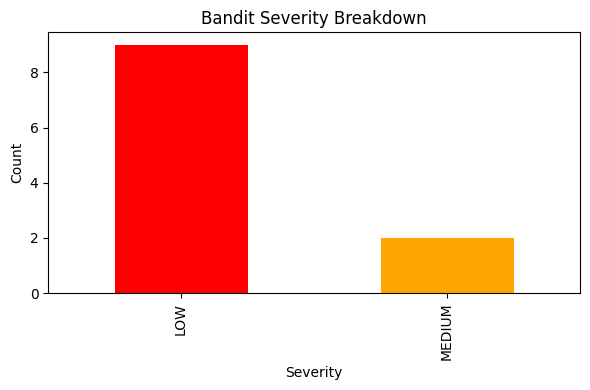

In [16]:
# Bandit severity bar chart
if not df_bandit.empty:
    severity_counts = df_bandit["severity"].value_counts()

    plt.figure(figsize=(6, 4))
    severity_counts.plot(kind="bar", color=["red", "orange", "yellow", "green"])
    plt.title("Bandit Severity Breakdown")
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No Bandit findings to plot.")

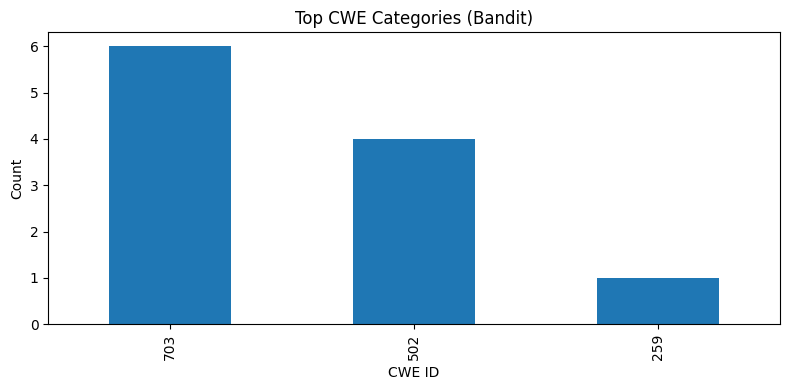

In [17]:
# CWE bar chart (top 10)
if not df_bandit.empty:
    cwe_counts = df_bandit["cwe"].value_counts().head(10)

    plt.figure(figsize=(8, 4))
    cwe_counts.plot(kind="bar")
    plt.title("Top CWE Categories (Bandit)")
    plt.xlabel("CWE ID")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No Bandit findings to plot CWEs.")

## 8. Build Top 10 Critical Vulnerabilities (risk scoring)

We approximate risk as:

- Map severity → numeric score
- Assume a default exploitability score
- Risk score = severity_score × exploitability

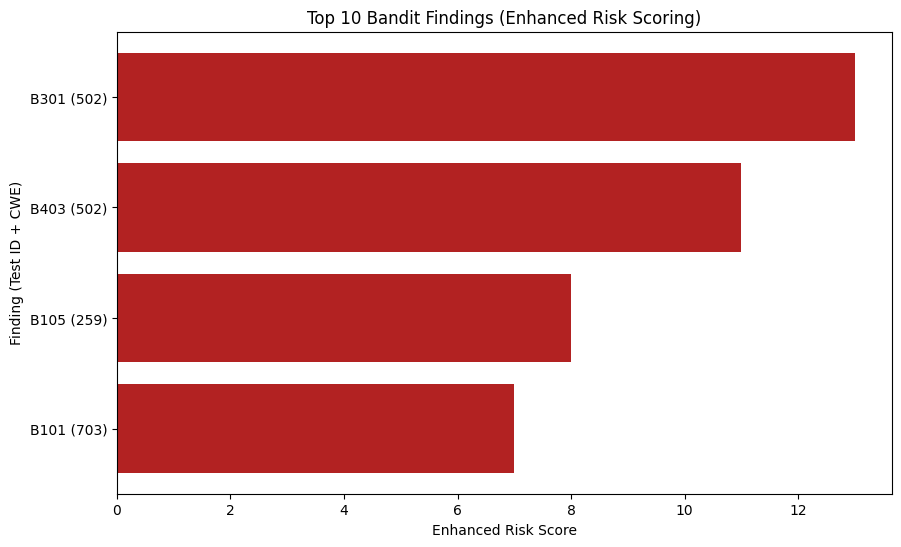

In [18]:
import matplotlib.pyplot as plt

# Enhanced scoring maps
severity_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3, "CRITICAL": 4}
confidence_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

# CWE weighting (higher weight for dangerous categories)
cwe_weight = {
    "502": 3,   # Deserialization of untrusted data (high risk)
    "259": 2,   # Hardcoded password
    "703": 1,   # Improper exception handling
}

# Apply enhanced scoring
df_bandit["severity_score"] = df_bandit["severity"].map(severity_score).fillna(1)
df_bandit["confidence_score"] = df_bandit["confidence"].map(confidence_score).fillna(1)
df_bandit["cwe_weight"] = df_bandit["cwe"].astype(str).map(cwe_weight).fillna(1)

# Enhanced risk score formula
df_bandit["risk_score"] = (
    df_bandit["severity_score"] * 2 +
    df_bandit["confidence_score"] * 1 +
    df_bandit["cwe_weight"] * 2
)

# Build Top 10
top10 = df_bandit.sort_values("risk_score", ascending=False).head(10)
top10_display = top10[["file", "line", "test_id", "cwe", "severity", "confidence", "risk_score", "text"]]
top10_display

plt.figure(figsize=(10,6))
plt.barh(top10["test_id"] + " (" + top10["cwe"].astype(str) + ")", top10["risk_score"], color="firebrick")
plt.xlabel("Enhanced Risk Score")
plt.ylabel("Finding (Test ID + CWE)")
plt.title("Top 10 Bandit Findings (Enhanced Risk Scoring)")
plt.gca().invert_yaxis()
plt.show()

## 9. Generate Deliverable 1 — Security Scan Results Report (Markdown)

Creates: `deliverables/Module1_Security_Report.md`

In [20]:
!pip install tabulate

report_path = "deliverables/Module1_Security_Report.md"

with open(report_path, "w") as f:
    f.write("# Security Scan Results Report\n\n")
    f.write("## Executive Summary\n")
    f.write("This report summarizes the results of automated static analysis using Bandit, Semgrep, PyLint, and Safety on the ML training codebase. ")
    f.write("The goal is to identify hardcoded credentials, unsafe pickle operations, and exposed API keys, then prioritize remediation.\n\n")

    f.write("## Tool Summary\n")
    f.write(f"- Bandit findings: {len(df_bandit)}\\n")
    f.write(f"- Semgrep findings: {len(df_semgrep)}\\n")
    f.write(f"- Safety vulnerabilities (raw entries): {len(safety)}\\n\\n")

    f.write("## Bandit Severity Breakdown\n\n")
    if not df_bandit.empty:
        f.write(df_bandit["severity"].value_counts().to_markdown() + "\n\n")
    else:
        f.write("_No Bandit findings._\n\n")

    f.write("## Bandit Findings by CWE\n\n")
    if not df_bandit.empty:
        f.write(df_bandit.groupby("cwe").size().to_markdown() + "\n\n")
    else:
        f.write("_No Bandit findings._\n\n")

    f.write("## Semgrep Findings by Rule\n\n")
    if not df_semgrep.empty:
        f.write(df_semgrep.groupby("rule").size().to_markdown() + "\n\n")
    else:
        f.write("_No Semgrep findings._\n\n")

    f.write("## Top 10 Critical Vulnerabilities (Bandit-based)\n\n")
    if not top10.empty:
        f.write(top10[["file", "line", "test_id", "cwe", "severity", "risk_score", "text"]].to_markdown() + "\n\n")
    else:
        f.write("_No critical vulnerabilities identified._\n\n")

    f.write("## Remediation Recommendations (High Level)\n")
    f.write("- Remove hardcoded credentials and move them to environment variables or secret managers.\\n")
    f.write("- Replace unsafe pickle deserialization with safer formats (e.g., JSON, ONNX, safetensors).\\n")
    f.write("- Add input validation and strict allowlists for file paths and external inputs.\\n")
    f.write("- Enforce automated scanning in CI/CD using GitHub Actions.\\n")

print(f"Deliverable 1 written to {report_path}")

Deliverable 1 written to deliverables/Module1_Security_Report.md


## 10. Generate Deliverable 2 — GitHub Actions Workflow (YAML)

Creates: `deliverables/security-scan.yml`

In [21]:
workflow_path = "deliverables/security-scan.yml"

workflow = """name: Security Scan

on:
  pull_request:
    branches: [ main, master ]

jobs:
  security-scan:
    runs-on: ubuntu-latest
    steps:
      - name: Checkout code
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: '3.11'

      - name: Install dependencies
        run: |
          pip install bandit semgrep safety

      - name: Run Bandit
        run: |
          bandit -r . -f json -o security-reports/bandit-results.json || true

      - name: Run Semgrep
        run: |
          semgrep --config=auto . --json --output security-reports/semgrep-results.json || true

      - name: Run Safety
        run: |
          safety check --json > security-reports/safety-results.json || true

      - name: Upload security reports
        uses: actions/upload-artifact@v4
        with:
          name: security-reports
          path: security-reports/

      - name: Fail on HIGH severity (Bandit)
        run: |
          python - << 'EOF'
          import json
          import sys
          try:
              with open('security-reports/bandit-results.json') as f:
                  data = json.load(f)
          except FileNotFoundError:
              print('No Bandit report found. Skipping fail step.')
              sys.exit(0)
          highs = [r for r in data.get('results', []) if r.get('issue_severity') in ('HIGH','CRITICAL')]
          if highs:
              print(f"Found {len(highs)} HIGH/CRITICAL issues. Failing build.")
              sys.exit(1)
          print('No HIGH/CRITICAL issues found.')
          EOF
"""

with open(workflow_path, "w") as f:
    f.write(workflow)

print(f"Deliverable 2 written to {workflow_path}")

Deliverable 2 written to deliverables/security-scan.yml


## 11. Generate Deliverable 3 — Remediation Priority Matrix (CSV)

Creates: `deliverables/remediation_matrix.csv`

In [22]:
matrix_path = "deliverables/remediation_matrix.csv"

if not top10.empty:
    def remediation_hint(row):
        tid = row.get("test_id", "")
        if tid in ("B105", "B106"):
            return "Remove hardcoded credentials; use env vars or secret manager."
        if tid in ("B301", "B403"):
            return "Replace pickle with safer serialization (e.g., JSON, ONNX)."
        return "Apply secure coding fix based on CWE and test_id."

    df_matrix = top10.copy()
    df_matrix["remediation"] = df_matrix.apply(remediation_hint, axis=1)
    df_matrix["estimated_time_hours"] = 2  # simple default

    df_matrix[[
        "file",
        "line",
        "test_id",
        "cwe",
        "severity",
        "risk_score",
        "remediation",
        "estimated_time_hours",
    ]].to_csv(matrix_path, index=False)

    print(f"Deliverable 3 written to {matrix_path}")
else:
    print("No Bandit findings; remediation matrix not generated.")

Deliverable 3 written to deliverables/remediation_matrix.csv


## 12. Final confirmation

In [23]:
print("Deliverables generated:")
print(os.listdir("deliverables"))

Deliverables generated:
['remediation_matrix.csv', 'security-scan.yml', 'Module1_Security_Report.md']
